In [1]:
# for data loading mostly
import numpy as np
import pandas as pd
import mne

# for csp and lda
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
# pretty sure sfreq is 250hz

def csv_to_raw(csv_path, sfreq, eeg_chs):
    df = pd.read_csv(csv_path)

    data = df[eeg_chs].values.T  # (channels, samples)

    info = mne.create_info(
        ch_names=eeg_chs,
        sfreq=sfreq,
        ch_types=["eeg"] * len(eeg_chs)
    )

    raw = mne.io.RawArray(data, info)
    raw.set_montage("standard_1020")

    return raw

In [3]:
s_freq = 250 # CHECK
eeg_chs = ['C3', 'Cz', 'C4']
data_dir = "."

In [4]:
epoch_len = 2.0  # in sec

In [5]:
# Loop over all experiment pairs and run CSP/LDA analysis
import os
import numpy as np
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

def csv_to_raw(csv_path, sfreq, eeg_chs):
    df = pd.read_csv(csv_path)
    data = df[eeg_chs].values.T  # (channels, samples)
    info = mne.create_info(
        ch_names=eeg_chs,
        sfreq=sfreq,
        ch_types=["eeg"] * len(eeg_chs)
    )
    raw = mne.io.RawArray(data, info)
    raw.set_montage("standard_1020")
    return raw

s_freq = 250
eeg_chs = ['C3', 'Cz', 'C4']
data_dir = 'experiment_data'
epoch_len = 2.0  # in sec

for i in range(1, 6):  # Adjust range as needed
    control_path = os.path.join(data_dir, f'Experiment_#{i}_Control.csv')
    leg_path = os.path.join(data_dir, f'Experiment_#{i}_LEG_MI.csv')
    if not (os.path.exists(control_path) and os.path.exists(leg_path)):
        continue

    raw_rest = csv_to_raw(control_path, s_freq, eeg_chs)
    raw_mi = csv_to_raw(leg_path, s_freq, eeg_chs)

    raw_rest.filter(8, 30, picks='eeg')
    raw_mi.filter(8, 30, picks='eeg')

    epochs_rest = mne.make_fixed_length_epochs(
        raw_rest, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )
    epochs_mi = mne.make_fixed_length_epochs(
        raw_mi, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )

    X_rest = epochs_rest.get_data()
    X_mi = epochs_mi.get_data()
    y_rest = np.zeros(len(X_rest))
    y_mi = np.ones(len(X_mi))

    X = np.concatenate([X_mi, X_rest], axis=0)
    y = np.concatenate([y_mi, y_rest], axis=0)

    pipeline = Pipeline([
        ("csp", CSP(n_components=2, log=True)),
        ("lda", LinearDiscriminantAnalysis())
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X, y, cv=cv, scoring="accuracy"
    )

    print(f"Experiment #{i}")
    print("Fold accuracies:", scores)
    print("Mean accuracy:", scores.mean())
    print("-" * 30)


Creating RawArray with float64 data, n_channels=3, n_times=5060
    Range : 0 ... 5059 =      0.000 ...    20.236 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5102
    Range : 0 ... 5101 =      0.000 ...    20.404 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+03 (2.2e-16 eps * 3 dim * 1.6e+18  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+03 (2.2e-16 eps * 3 dim * 1.6e+18  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 500 original time points ...
0 bad epochs dropped
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 500 original time points ...
0 bad epochs dropped
Computing rank from data with rank=None
    Using tolerance 7.7e+02 (2.2e-16 eps * 3 dim * 1.2e+18  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+03 (2.2e-16 eps * 3 dim * 1.6e+18  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Creating RawArray with float64 data, n_channels=3, n_times=5060
    Range : 0 ... 5059 =      0.000 ...    20.236 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5102
    Range : 0 ... 5101 =      0.000 ...    20.404 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 19 events and 500 original time points ...
0 bad epochs dropped
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective wind

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

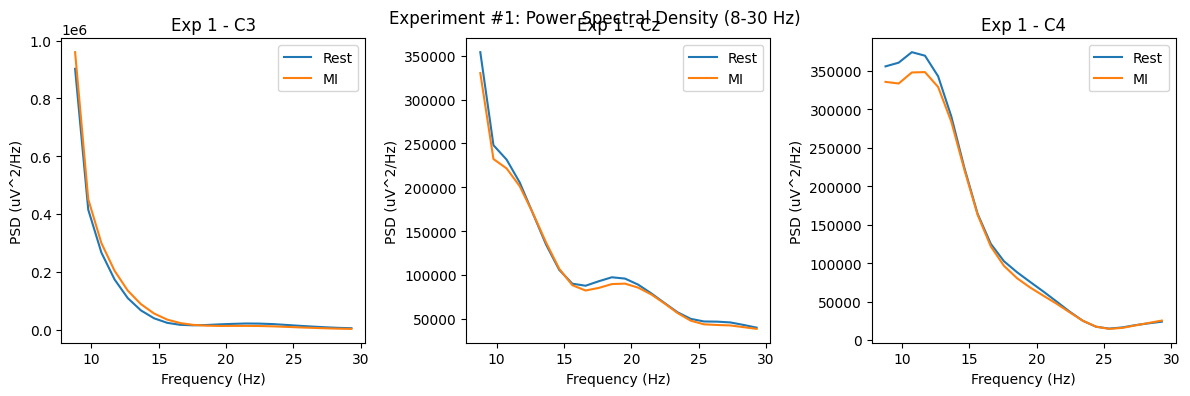

Creating RawArray with float64 data, n_channels=3, n_times=4944
    Range : 0 ... 4943 =      0.000 ...    19.772 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5125
    Range : 0 ... 5124 =      0.000 ...    20.496 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

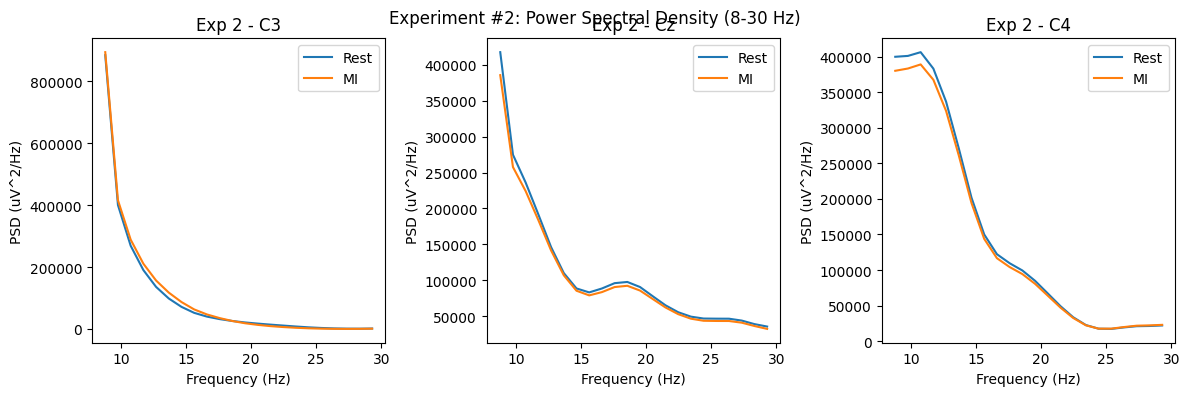

Creating RawArray with float64 data, n_channels=3, n_times=5012
    Range : 0 ... 5011 =      0.000 ...    20.044 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5038
    Range : 0 ... 5037 =      0.000 ...    20.148 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 19 events and 500 original time points ...
0 bad epochs dropped
Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 19 events and 500 original time points ...
0 bad epochs dropped
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Effective wind

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

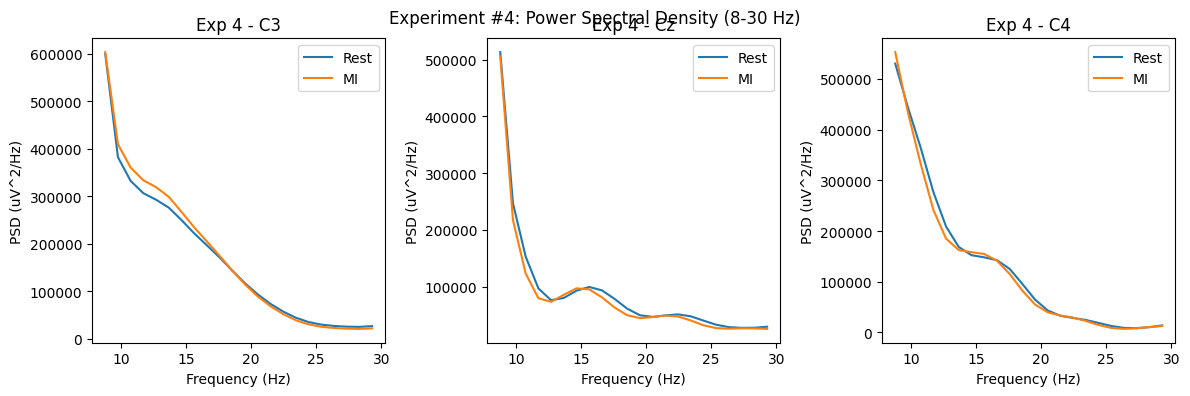

Creating RawArray with float64 data, n_channels=3, n_times=4967
    Range : 0 ... 4966 =      0.000 ...    19.864 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=4990
    Range : 0 ... 4989 =      0.000 ...    19.956 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

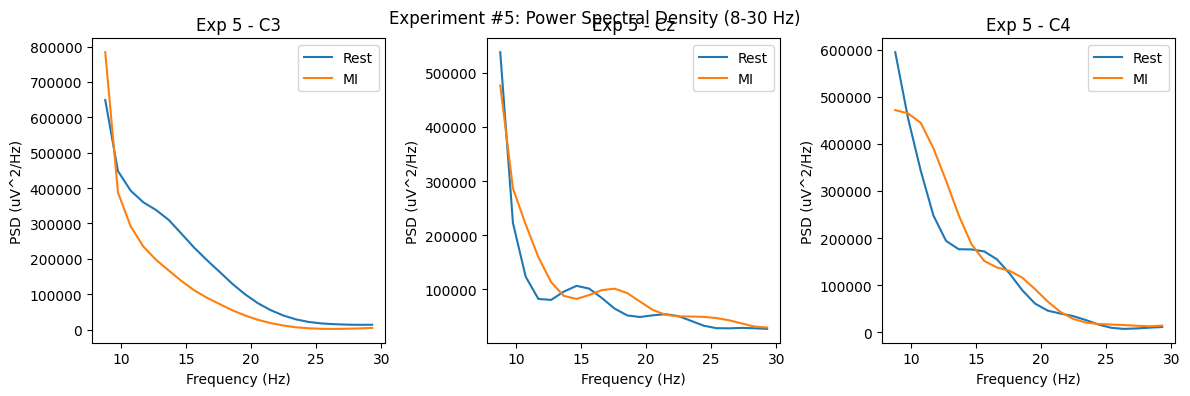

In [6]:
# Frequency-based analysis: plot average power spectral density (PSD) for each channel and condition
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_welch

for i in range(1, 6):
    control_path = os.path.join(data_dir, f'Experiment_#{i}_Control.csv')
    leg_path = os.path.join(data_dir, f'Experiment_#{i}_LEG_MI.csv')
    if not (os.path.exists(control_path) and os.path.exists(leg_path)):
        continue

    raw_rest = csv_to_raw(control_path, s_freq, eeg_chs)
    raw_mi = csv_to_raw(leg_path, s_freq, eeg_chs)

    raw_rest.filter(8, 30, picks='eeg')
    raw_mi.filter(8, 30, picks='eeg')

    epochs_rest = mne.make_fixed_length_epochs(
        raw_rest, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )
    epochs_mi = mne.make_fixed_length_epochs(
        raw_mi, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )

    X_rest = epochs_rest.get_data()  # shape: (n_epochs, n_channels, n_times)
    X_mi = epochs_mi.get_data()

    # Compute PSD for each epoch, then average
    psds_rest = []
    psds_mi = []
    for ep in X_rest:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_rest.append(psd)
    for ep in X_mi:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_mi.append(psd)
    psds_rest = np.array(psds_rest)  # (n_epochs, n_channels, n_freqs)
    psds_mi = np.array(psds_mi)

    # Average across epochs
    mean_psd_rest = np.mean(psds_rest, axis=0)  # (n_channels, n_freqs)
    mean_psd_mi = np.mean(psds_mi, axis=0)

    # Plot
    plt.figure(figsize=(12, 4))
    for idx, ch in enumerate(eeg_chs):
        plt.subplot(1, 3, idx+1)
        plt.plot(freqs, mean_psd_rest[idx], label='Rest', color='tab:blue')
        plt.plot(freqs, mean_psd_mi[idx], label='MI', color='tab:orange')
        plt.title(f'Exp {i} - {ch}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('PSD (uV^2/Hz)')
        plt.legend()
        plt.tight_layout()
    plt.suptitle(f'Experiment #{i}: Power Spectral Density (8-30 Hz)')
    plt.show()


In [7]:
# Calculate and plot percent power change (ERD) in mu (8-13 Hz) and beta (13-30 Hz) bands
mu_band = (8, 13)
beta_band = (13, 30)

for i in range(1, 6):
    control_path = os.path.join(data_dir, f'Experiment_#{i}_Control.csv')
    leg_path = os.path.join(data_dir, f'Experiment_#{i}_LEG_MI.csv')
    if not (os.path.exists(control_path) and os.path.exists(leg_path)):
        continue

    raw_rest = csv_to_raw(control_path, s_freq, eeg_chs)
    raw_mi = csv_to_raw(leg_path, s_freq, eeg_chs)

    raw_rest.filter(8, 30, picks='eeg')
    raw_mi.filter(8, 30, picks='eeg')

    epochs_rest = mne.make_fixed_length_epochs(
        raw_rest, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )
    epochs_mi = mne.make_fixed_length_epochs(
        raw_mi, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )

    X_rest = epochs_rest.get_data()
    X_mi = epochs_mi.get_data()

    # Compute PSD for each epoch, then average
    psds_rest = []
    psds_mi = []
    for ep in X_rest:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_rest.append(psd)
    for ep in X_mi:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_mi.append(psd)
    psds_rest = np.array(psds_rest)
    psds_mi = np.array(psds_mi)
    mean_psd_rest = np.mean(psds_rest, axis=0)  # (n_channels, n_freqs)
    mean_psd_mi = np.mean(psds_mi, axis=0)

    # Calculate mean power in mu and beta bands for each channel
    mu_idx = np.where((freqs >= mu_band[0]) & (freqs < mu_band[1]))[0]
    beta_idx = np.where((freqs >= beta_band[0]) & (freqs <= beta_band[1]))[0]

    for idx, ch in enumerate(eeg_chs):
        mu_power_rest = np.mean(mean_psd_rest[idx, mu_idx])
        mu_power_mi = np.mean(mean_psd_mi[idx, mu_idx])
        beta_power_rest = np.mean(mean_psd_rest[idx, beta_idx])
        beta_power_mi = np.mean(mean_psd_mi[idx, beta_idx])
        mu_erd = 100 * (mu_power_mi - mu_power_rest) / mu_power_rest
        beta_erd = 100 * (beta_power_mi - beta_power_rest) / beta_power_rest
        print(f"Experiment {i} | Channel {ch}:")
        print(f"  Mu band (8-13 Hz) percent change: {mu_erd:.1f}%")
        print(f"  Beta band (13-30 Hz) percent change: {beta_erd:.1f}%")
    print("-" * 40)


Creating RawArray with float64 data, n_channels=3, n_times=5060
    Range : 0 ... 5059 =      0.000 ...    20.236 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5102
    Range : 0 ... 5101 =      0.000 ...    20.404 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 500 original time points ...
0 bad epochs dropped
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 500 original time points ...
0 bad epochs dropped
Effective window size : 1.024 (

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Creating RawArray with float64 data, n_channels=3, n_times=5060
    Range : 0 ... 5059 =      0.000 ...    20.236 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5102
    Range : 0 ... 5101 =      0.000 ...    20.404 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass fil

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.024 (s)
Effective window size : 1.024 (s)
Creating RawArray with float64 data, n_channels=3, n_times=5012
    Range : 0 ... 5011 =      0.000 ...    20.044 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5038
    Range : 0 ... 5037 =      0.000 ...    20.148 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
-----------

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Creating RawArray with float64 data, n_channels=3, n_times=4990
    Range : 0 ... 4989 =      0.000 ...    19.956 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

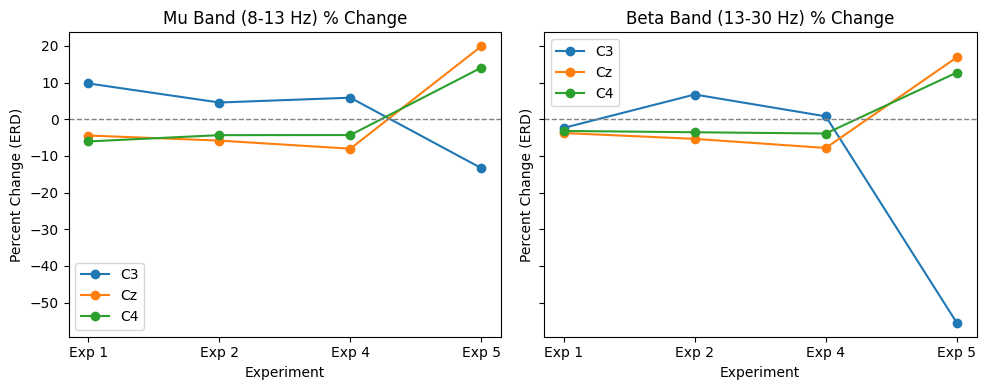

In [8]:
# Plot percent power change (ERD) for mu and beta bands, per channel and experiment
mu_band = (8, 13)
beta_band = (13, 30)

mu_erds = []  # shape: (n_experiments, n_channels)
beta_erds = []
exp_labels = []

for i in range(1, 6):
    control_path = os.path.join(data_dir, f'Experiment_#{i}_Control.csv')
    leg_path = os.path.join(data_dir, f'Experiment_#{i}_LEG_MI.csv')
    if not (os.path.exists(control_path) and os.path.exists(leg_path)):
        continue

    raw_rest = csv_to_raw(control_path, s_freq, eeg_chs)
    raw_mi = csv_to_raw(leg_path, s_freq, eeg_chs)

    raw_rest.filter(8, 30, picks='eeg')
    raw_mi.filter(8, 30, picks='eeg')

    epochs_rest = mne.make_fixed_length_epochs(
        raw_rest, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )
    epochs_mi = mne.make_fixed_length_epochs(
        raw_mi, duration=epoch_len, overlap=epoch_len / 2, preload=True
    )

    X_rest = epochs_rest.get_data()
    X_mi = epochs_mi.get_data()

    # Compute PSD for each epoch, then average
    psds_rest = []
    psds_mi = []
    for ep in X_rest:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_rest.append(psd)
    for ep in X_mi:
        psd, freqs = psd_array_welch(ep, sfreq=s_freq, fmin=8, fmax=30, n_fft=256)
        psds_mi.append(psd)
    psds_rest = np.array(psds_rest)
    psds_mi = np.array(psds_mi)
    mean_psd_rest = np.mean(psds_rest, axis=0)  # (n_channels, n_freqs)
    mean_psd_mi = np.mean(psds_mi, axis=0)

    mu_idx = np.where((freqs >= mu_band[0]) & (freqs < mu_band[1]))[0]
    beta_idx = np.where((freqs >= beta_band[0]) & (freqs <= beta_band[1]))[0]

    mu_erd_ch = []
    beta_erd_ch = []
    for idx, ch in enumerate(eeg_chs):
        mu_power_rest = np.mean(mean_psd_rest[idx, mu_idx])
        mu_power_mi = np.mean(mean_psd_mi[idx, mu_idx])
        beta_power_rest = np.mean(mean_psd_rest[idx, beta_idx])
        beta_power_mi = np.mean(mean_psd_mi[idx, beta_idx])
        mu_erd = 100 * (mu_power_mi - mu_power_rest) / mu_power_rest
        beta_erd = 100 * (beta_power_mi - beta_power_rest) / beta_power_rest
        mu_erd_ch.append(mu_erd)
        beta_erd_ch.append(beta_erd)
    mu_erds.append(mu_erd_ch)
    beta_erds.append(beta_erd_ch)
    exp_labels.append(f'Exp {i}')

mu_erds = np.array(mu_erds)  # (n_exp, n_ch)
beta_erds = np.array(beta_erds)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for idx, ch in enumerate(eeg_chs):
    axs[0].plot(exp_labels, mu_erds[:, idx], marker='o', label=ch)
    axs[1].plot(exp_labels, beta_erds[:, idx], marker='o', label=ch)
axs[0].set_title('Mu Band (8-13 Hz) % Change')
axs[1].set_title('Beta Band (13-30 Hz) % Change')
for ax in axs:
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Experiment')
    ax.set_ylabel('Percent Change (ERD)')
    ax.legend()
plt.tight_layout()
plt.show()
